In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')
from scipy import stats

# Custom font (optional)
font_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

In [15]:
specifiedpath = "D:\\"
filepath = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_bothresponders_Full.xlsx"

df = pd.read_excel(filepath)


In [16]:
df

,MBON,responder,PI_Hg_OSAR,Log2 Speed ratio_Hg_OSAR,Log2 Bout Speed ratio_Hg_OSAR,Light Attraction Index_Hg_OSAR,Bout Number Index_Hg_OSAR,Bout Duration ratio_Hg_OSAR,Max Velocity ratio_Hg_OSAR,Speed ratio_Hg_OSAR,Bout Speed ratio_Hg_OSAR
0,VT999036,Chrimson2,-0.867722,-0.122377,2.280033,-1.339126,-2.482901,-0.652042,-0.864104,-0.212177,2.201109
1,SS75200,Chrimson2,-0.616998,0.418496,-0.631509,-0.020474,0.421011,-0.078908,-0.028081,0.053898,-0.475233
2,SS75199,Chrimson2,-0.499194,0.428542,0.100097,-0.102365,-0.152323,-0.066585,-0.184665,0.374848,0.155152
3,MB434B,Chrimson2,-0.484317,0.363749,-0.602173,-0.361077,-0.341151,-0.184864,-0.067421,0.144010,-0.629100
4,SS46348,Chrimson2,-0.467341,0.226340,0.020302,0.041174,-0.302430,-0.216989,0.336238,0.144873,-0.236886
...,...,...,...,...,...,...,...,...,...,...,...
61,MB210B,ACR,0.356944,-0.308443,-0.434633,0.178198,0.266676,0.023319,-0.087966,-0.123774,-0.253793
62,SS80958,ACR,0.393372,-0.660028,-0.598947,-0.325403,-0.075664,0.343694,-0.114683,-0.231486,-0.499542
63,SS67741,ACR,0.536344,-0.172695,-0.538959,-0.103099,0.571744,0.461694,0.114728,0.300415,-0.660753
64,SS77383,ACR,0.644212,-0.761763,0.105046,0.248181,-0.251036,-0.155340,-0.293482,-0.454819,0.241147


In [25]:
acr = df[df['responder'] == 'ACR'].set_index('MBON')
chrimson = df[df['responder'] == 'Chrimson2'].set_index('MBON')

acr = acr.drop(index=["R76B09", "VT999036"], errors="ignore")
chrimson = chrimson.drop(index=["R76B09", "VT999036"], errors="ignore")

mbons = acr.index.intersection(chrimson.index)
acr = acr.loc[mbons]
chrimson = chrimson.loc[mbons]

pref_acr = (acr['PI_Hg_OSAR'].abs() + acr['Light Attraction Index_Hg_OSAR'].abs()) / 2
pref_chr = (chrimson['PI_Hg_OSAR'].abs() + chrimson['Light Attraction Index_Hg_OSAR'].abs()) / 2

loco_acr = (acr['Log2 Bout Speed ratio_Hg_OSAR'].abs() + acr['Bout Number Index_Hg_OSAR'].abs() + acr['Bout Duration ratio_Hg_OSAR'].abs() + acr['Max Velocity ratio_Hg_OSAR'].abs()) / 4
loco_chr = (chrimson['Log2 Bout Speed ratio_Hg_OSAR'].abs() + chrimson['Bout Number Index_Hg_OSAR'].abs() + chrimson['Bout Duration ratio_Hg_OSAR'].abs() + chrimson['Max Velocity ratio_Hg_OSAR'].abs()) / 4

comb_acr = (pref_acr + loco_acr) / 2
comb_chr = (pref_chr + loco_chr) / 2

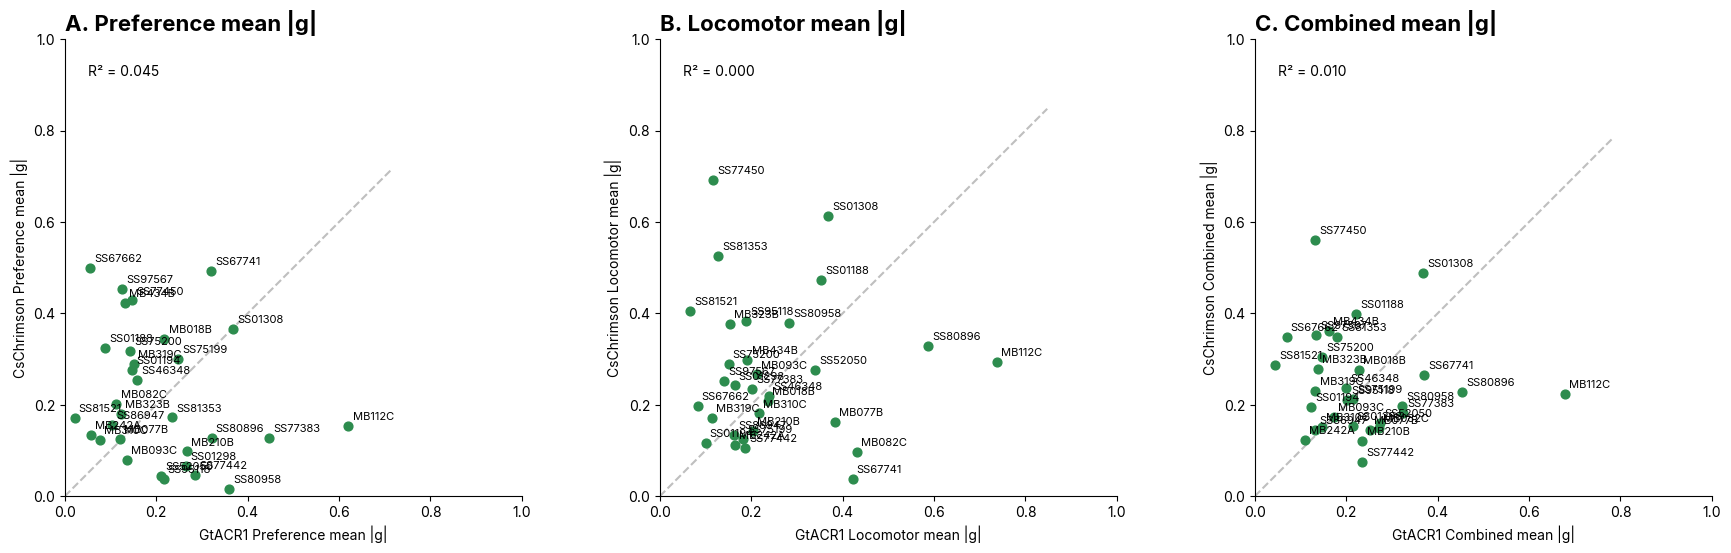

In [21]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (pref_acr, pref_chr, 'Preference mean |g|'),
    (loco_acr, loco_chr, 'Locomotor mean |g|'),
    (comb_acr, comb_chr, 'Combined mean |g|'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (x, y, title), label in zip(axes, panels, ['A', 'B', 'C']):
    ax.scatter(x, y, s=40, color='#2D8C4E', zorder=3)

    for mbon in mbons:
        ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel(f'GtACR1 {title}', fontsize=10)
    ax.set_ylabel(f'CsChrimson {title}', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\phenomics" + date +".svg", bbox_inches='tight')
plt.show()

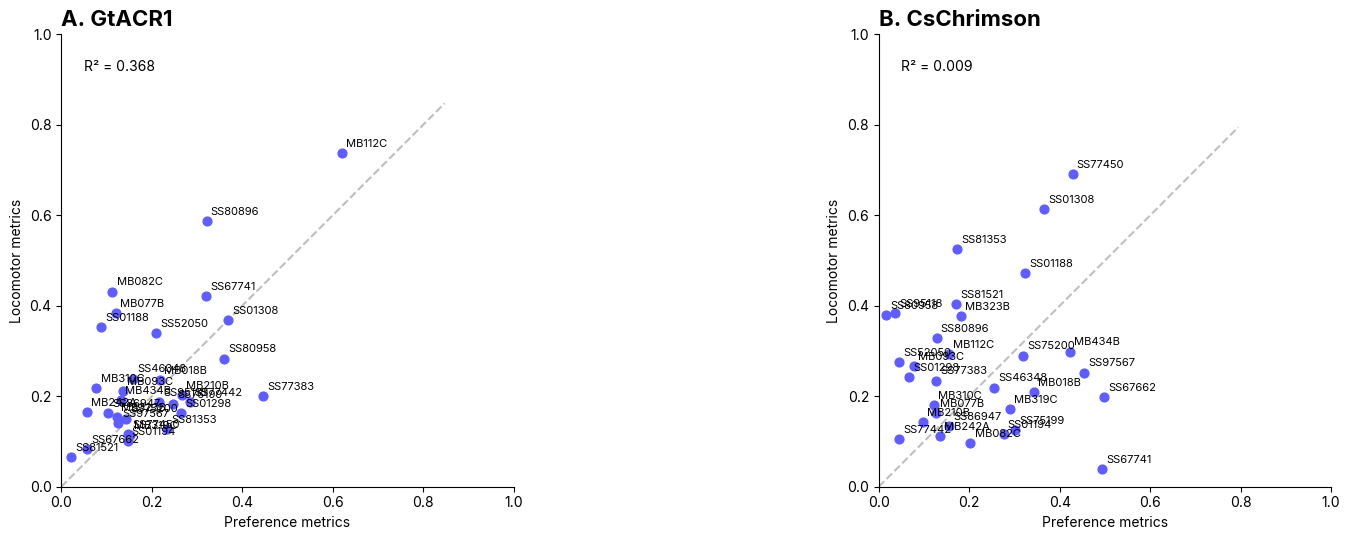

In [26]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (pref_acr,loco_acr, 'GtACR1'),
    (pref_chr, loco_chr, 'CsChrimson')
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

for ax, (x, y, title), label in zip(axes, panels, ['A', 'B']):
    ax.scatter(x, y, s=40, color="#5F5DFF", zorder=3)

    for mbon in mbons:
        ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel(f'Preference metrics', fontsize=10)
    ax.set_ylabel(f'Locomotor metrics', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\phenomics" + date +".svg", bbox_inches='tight')
plt.show()

In [10]:
df_total = pd.DataFrame()
df_total["Preference mean_ACR"] = pref_acr
df_total["Preference mean_Chrimson2"] = pref_chr
df_total["Locomotor mean_ACR"] = loco_acr
df_total["Locomotor mean_Chrimson2"] =loco_chr
df_total["Combined mean_ACR"] = comb_acr
df_total["Combined mean_Chrimson2"] = comb_chr


In [11]:
pref_cols = ["PI_Hg_OSAR", "Light Attraction Index_Hg_OSAR"]
loco_cols = ["Log2 Bout Speed ratio_Hg_OSAR", "Bout Number Index_Hg_OSAR", "Bout Duration ratio_Hg_OSAR", "Max Velocity ratio_Hg_OSAR"]
all_cols = pref_cols + loco_cols

acr_means = acr[all_cols].abs().mean()
chr_means = chrimson[all_cols].abs().mean()
acr_stds = acr[all_cols].abs().std()
chr_stds = chrimson[all_cols].abs().std()
n_acr_count = acr[all_cols].count()
n_chr_count = chrimson[all_cols].count()

ci95_acr_val = 1.96 * acr_stds / np.sqrt(n_acr_count)
ci95_chr_val = 1.96 * chr_stds / np.sqrt(n_chr_count)

group = ["preference"] * len(pref_cols) + ["locomotor"] * len(loco_cols)

result_osar = pd.DataFrame({
    "metric": all_cols,
    "group": group,
    "GtACR1": acr_means.values,
    "GtACR1_CI_low": (acr_means - ci95_acr_val).values,
    "GtACR1_CI_high": (acr_means + ci95_acr_val).values,
    "CsChrimson": chr_means.values,
    "CsChrimson_CI_low": (chr_means - ci95_chr_val).values,
    "CsChrimson_CI_high": (chr_means + ci95_chr_val).values,
})
result_osar

,metric,group,GtACR1,GtACR1_CI_low,GtACR1_CI_high,CsChrimson,CsChrimson_CI_low,CsChrimson_CI_high
0,PI_Hg_OSAR,preference,0.245270,0.163530,0.327010,0.260755,0.188620,0.332890
1,Light Attraction Index_Hg_OSAR,preference,0.191520,0.120723,0.262317,0.235119,0.144350,0.325888
2,Log2 Bout Speed ratio_Hg_OSAR,locomotor,0.366950,0.270046,0.463853,0.368457,0.220726,0.516189
3,Bout Number Index_Hg_OSAR,locomotor,0.228425,0.136000,0.320851,0.394333,0.214934,0.573731
4,Bout Duration ratio_Hg_OSAR,locomotor,0.217011,0.149048,0.284973,0.220083,0.165090,0.275076
5,Max Velocity ratio_Hg_OSAR,locomotor,0.278002,0.136372,0.419632,0.256531,0.183570,0.329493


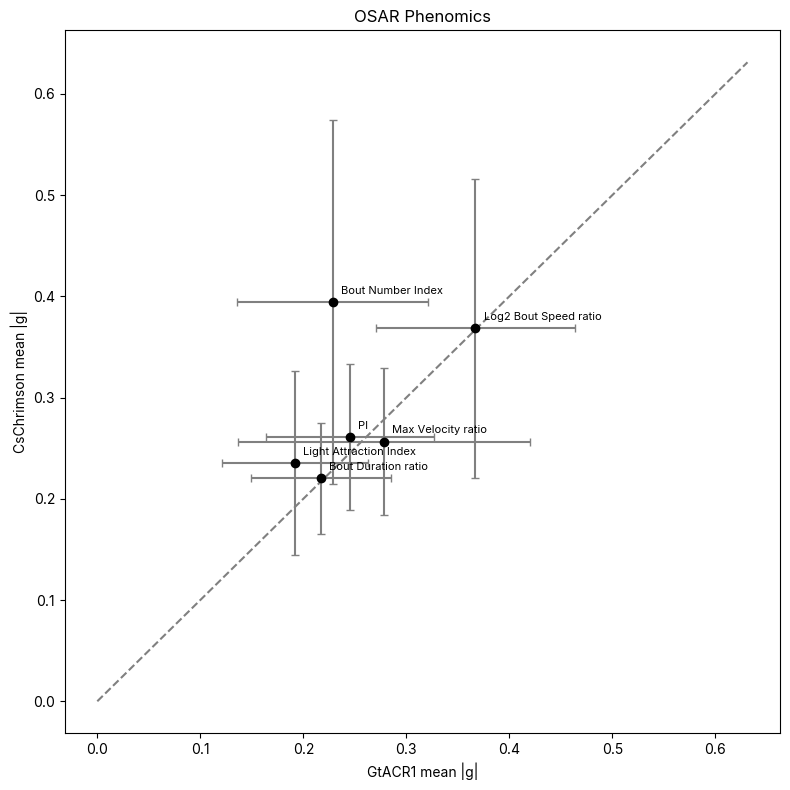

In [12]:
xerr_low = result_osar["GtACR1"] - result_osar["GtACR1_CI_low"]
xerr_high = result_osar["GtACR1_CI_high"] - result_osar["GtACR1"]
yerr_low = result_osar["CsChrimson"] - result_osar["CsChrimson_CI_low"]
yerr_high = result_osar["CsChrimson_CI_high"] - result_osar["CsChrimson"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.errorbar(result_osar["GtACR1"], result_osar["CsChrimson"],
            xerr=[xerr_low, xerr_high], yerr=[yerr_low, yerr_high],
            fmt="o", capsize=3, color="black", ecolor="gray")

for i, row in result_osar.iterrows():
    label = row["metric"].replace("_Hg_OSAR", "")
    ax.annotate(label, (row["GtACR1"], row["CsChrimson"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

max_val = max(result_osar["GtACR1_CI_high"].max(), result_osar["CsChrimson_CI_high"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], linestyle="--", color="gray")

ax.set_xlabel("GtACR1 mean |g|")
ax.set_ylabel("CsChrimson mean |g|")
ax.set_title("OSAR Phenomics")
plt.tight_layout()
plt.show()

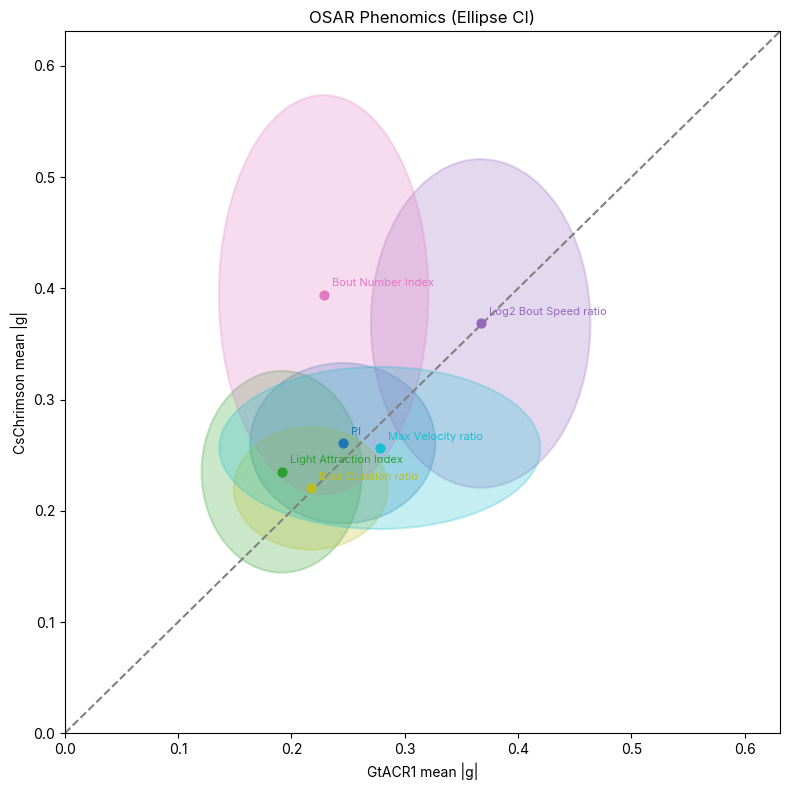

In [13]:
from matplotlib.patches import Ellipse

colors = plt.cm.tab10(np.linspace(0, 1, len(result_osar)))

fig, ax = plt.subplots(figsize=(8, 8))

for i, row in result_osar.iterrows():
    w = row["GtACR1_CI_high"] - row["GtACR1_CI_low"]
    h = row["CsChrimson_CI_high"] - row["CsChrimson_CI_low"]
    ellipse = Ellipse((row["GtACR1"], row["CsChrimson"]), width=w, height=h,
                       facecolor=colors[i], alpha=0.25, edgecolor=colors[i], linewidth=1.5)
    ax.add_patch(ellipse)
    ax.scatter(row["GtACR1"], row["CsChrimson"], color=colors[i], s=40, zorder=3)
    label = row["metric"].replace("_Hg_OSAR", "")
    ax.annotate(label, (row["GtACR1"], row["CsChrimson"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8, color=colors[i])

max_val = max(result_osar["GtACR1_CI_high"].max(), result_osar["CsChrimson_CI_high"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], linestyle="--", color="gray")

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel("GtACR1 mean |g|")
ax.set_ylabel("CsChrimson mean |g|")
ax.set_title("OSAR Phenomics (Ellipse CI)")
plt.tight_layout()
plt.show()